# Parte 1: Simulación de Procesos AR(1) y Regresión Espuria

Este notebook aborda la simulación de procesos autoregresivos de primer orden (AR(1)) y caminatas aleatorias para analizar el fenómeno de la regresión espuria y la efectividad de los errores estándar HAC (Newey-West).

### Bloque 0 - Importar Librerias

In [23]:
import os
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

### Bloque 1 - Cargar Path

In [24]:
BASE_DIR = Path(r"C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final")
DATA_DIR = BASE_DIR / "dataset"
RESULTS_DIR = BASE_DIR / "results"
GRAPHICS_DIR = RESULTS_DIR / "graphics"/"parte1"
TABLES_DIR = RESULTS_DIR / "tables" /"parte1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

### Bloque 2 - Funciones Base

In [25]:
def simular_ar1(shocks, a=1, b=0.5, y0=None):
    T = len(shocks)
    y = np.zeros(T)

    if y0 is None:
        y[0] = a / (1 - b)
    else:
        y[0] = y0

    for t in range(1, T):
        y[t] = a + b * y[t-1] + shocks[t]

    return y


def simular_random_walk(shocks, y0):
    T = len(shocks)
    y = np.zeros(T)
    y[0] = y0

    for t in range(1, T):
        y[t] = y[t-1] + shocks[t]

    return y


def regresiones_y_significancia(Y, X, alpha=0.10, maxlags_hac=12):
    resultados = []

    for i in range(10):
        y = Y[:, i]
        x = X[:, i]
        X_reg = sm.add_constant(x)

        modelo = sm.OLS(y, X_reg).fit()

        pvalue_usual = modelo.pvalues[1]
        significativo_usual = pvalue_usual < alpha

        cov_hac_matrix = cov_hac(modelo, nlags=maxlags_hac)
        se_hac = np.sqrt(np.diag(cov_hac_matrix))
        t_hac = modelo.params[1] / se_hac[1]
        pvalue_hac = 2 * (1 - stats.t.cdf(abs(t_hac), df=modelo.df_resid))
        significativo_hac = pvalue_hac < alpha

        resultados.append({
            "Regresión": f"Y{i+1} ~ X{i+1}",
            "k estimado": modelo.params[1],
            "p-value usual": pvalue_usual,
            "Significativo usual": significativo_usual,
            "p-value HAC": pvalue_hac,
            "Significativo HAC": significativo_hac,
            "R2": modelo.rsquared
        })

    return pd.DataFrame(resultados)


def graficar_regresiones(Y, X, titulo_general, nombre_archivo=None):
    fig, axes = plt.subplots(5, 2, figsize=(14, 20))
    axes = axes.flatten()
    resumen_graficos = []
    for i in range(10):
        y = Y[:, i]
        x = X[:, i]
        X_reg = sm.add_constant(x)
        modelo = sm.OLS(y, X_reg).fit()
        axes[i].scatter(x, y, alpha=0.35, s=12)
        axes[i].plot(x, modelo.predict(X_reg), linewidth=2)
        axes[i].set_title(
            f"Regresión {i+1}: Y{i+1} ~ X{i+1}\n"
            f"k={modelo.params[1]:.4f}, "
            f"p={modelo.pvalues[1]:.4f}, "
            f"R²={modelo.rsquared:.4f}"
        )
        axes[i].set_xlabel(f"X{i+1}")
        axes[i].set_ylabel(f"Y{i+1}")
        resumen_graficos.append({
            "Regresión": f"Y{i+1} ~ X{i+1}",
            "k estimado": modelo.params[1],
            "p-value usual": modelo.pvalues[1],
            "R2": modelo.rsquared
        })
    plt.suptitle(titulo_general, fontsize=18, y=1.02)
    plt.tight_layout()
    
    # NUEVO: Guardar gráfico si se especifica un nombre
    if nombre_archivo:
        plt.savefig(GRAPHICS_DIR / f"{nombre_archivo}.png", bbox_inches='tight')
        
    plt.show()
    return pd.DataFrame(resumen_graficos)

### Bloque 3 Simulación pregunta I - AR(1) estacionario con 0.4 < b < 0.7

In [26]:
np.random.seed(123)

T = 1000
n_series = 20

a = 1
b = 0.6

shocks_i = np.random.normal(0, 1, size=(T, n_series))

series_i = np.zeros((T, n_series))

for j in range(n_series):
    series_i[:, j] = simular_ar1(
        shocks=shocks_i[:, j],
        a=a,
        b=b,
        y0=1 / (1 - b)
    )

Y = series_i[:, :10]
X = series_i[:, 10:]

### Bloque 4 — Regresiones pregunta I

In [27]:
resultados_i = regresiones_y_significancia(
    Y,
    X,
    alpha=0.10,
    maxlags_hac=12
)

resultados_i

,Regresión,k estimado,p-value usual,Significativo usual,p-value HAC,Significativo HAC,R2
0,Y1 ~ X1,0.096617,0.003001,True,0.035567,True,0.008790
1,Y2 ~ X2,-0.021202,0.492497,False,0.630064,False,0.000472
2,Y3 ~ X3,0.015835,0.644474,False,0.733132,False,0.000213
3,Y4 ~ X4,0.065125,0.040296,True,0.114802,False,0.004207
4,Y5 ~ X5,0.028592,0.371059,False,0.517819,False,0.000802
5,Y6 ~ X6,0.034857,0.299627,False,0.461358,False,0.001078
6,Y7 ~ X7,-0.001187,0.969855,False,0.980828,False,0.000001
7,Y8 ~ X8,0.051122,0.102733,False,0.220381,False,0.002666
8,Y9 ~ X9,-0.072878,0.028473,True,0.144377,False,0.004800
9,Y10 ~ X10,-0.109060,0.000674,True,0.003448,True,0.011521


### Bloque 5 — Porcentaje de significancia pregunta I

In [28]:
porcentaje_usual_i = resultados_i["Significativo usual"].mean() * 100
porcentaje_hac_i = resultados_i["Significativo HAC"].mean() * 100

print(f"Porcentaje significativo al 10% con errores usuales: {porcentaje_usual_i:.2f}%")
print(f"Porcentaje significativo al 10% con errores HAC: {porcentaje_hac_i:.2f}%")

Porcentaje significativo al 10% con errores usuales: 40.00%
Porcentaje significativo al 10% con errores HAC: 20.00%


En el caso AR(1) estacionario con b = 0.6, se observa que el parámetro k resulta significativo al 10% en un 40% de las regresiones utilizando errores estándar usuales.

Al corregir la inferencia mediante errores estándar HAC, el porcentaje de significancia disminuye a 20%.

Dado que las series Y y X fueron generadas de forma independiente, teóricamente el coeficiente k debería ser igual a cero. Por lo tanto, los rechazos observados corresponden a falsos positivos.

La diferencia entre errores usuales y HAC muestra que la corrección HAC reduce parte de la significancia espuria asociada a la dependencia temporal de las series. Sin embargo, incluso con HAC, el porcentaje observado supera el 10% esperado bajo una inferencia ideal.

| Escenario | Nivel | Significancia usual | Significancia HAC |
|---|---:|---:|---:|
| AR(1), b = 0.6 | 10% | 40% | 20% |


### Bloque 6 — Gráficos pregunta I

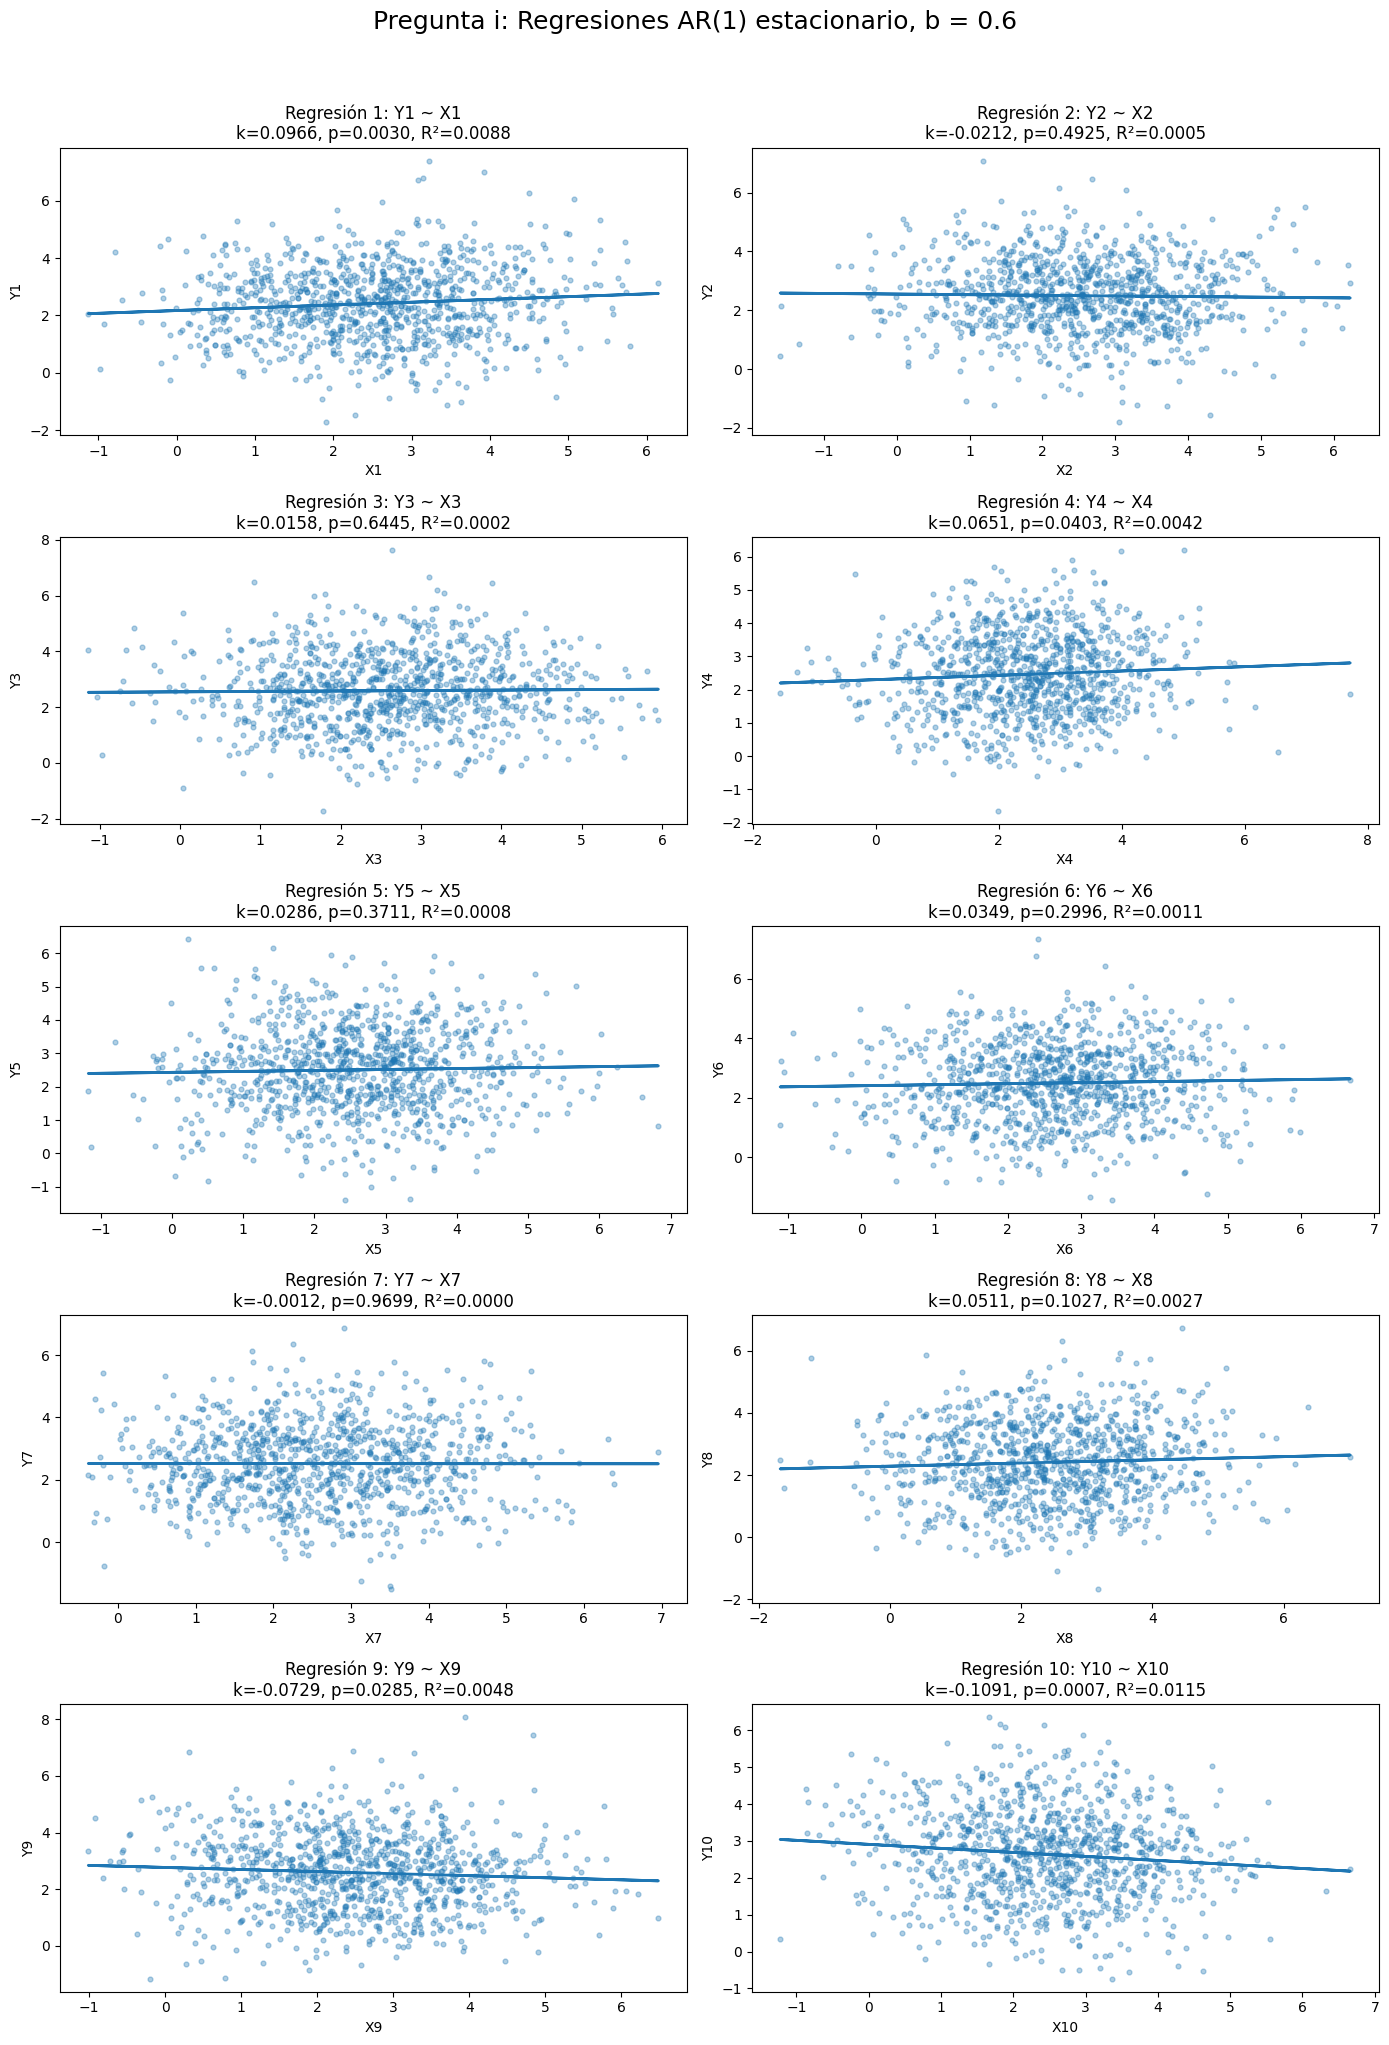

In [29]:
resumen_graficos_i = graficar_regresiones(
    Y,
    X,
    "Pregunta i: Regresiones AR(1) estacionario, b = 0.6",
    "Pregunta_i_AR1_estacionario"
)

### Bloque 7 - Simulación pregunta II - AR(1) altamente persistente con 0.95 < b < 0.99

In [30]:
np.random.seed(123)

T = 1000
n_series = 20

a = 1
b = 0.97

shocks_ii = np.random.normal(0, 1, size=(T, n_series))

series_ii = np.zeros((T, n_series))

for j in range(n_series):
    series_ii[:, j] = simular_ar1(
        shocks=shocks_ii[:, j],
        a=a,
        b=b,
        y0=1 / (1 - b)
    )

Y_persistente = series_ii[:, :10]
X_persistente = series_ii[:, 10:]

### Bloque 8 — Regresiones pregunta II

In [31]:
resultados_ii = regresiones_y_significancia(
    Y_persistente,
    X_persistente,
    alpha=0.10,
    maxlags_hac=12
)

resultados_ii

,Regresión,k estimado,p-value usual,Significativo usual,p-value HAC,Significativo HAC,R2
0,Y1 ~ X1,-0.095571,1.879570e-02,True,0.414577,False,0.005519
1,Y2 ~ X2,-0.002848,9.365407e-01,False,0.980984,False,0.000006
2,Y3 ~ X3,-0.065421,1.236953e-01,False,0.644248,False,0.002373
3,Y4 ~ X4,0.103726,2.977799e-04,True,0.185831,False,0.013031
4,Y5 ~ X5,-0.052577,1.725510e-01,False,0.632483,False,0.001864
5,Y6 ~ X6,0.228941,1.566787e-05,True,0.221996,False,0.018527
6,Y7 ~ X7,0.029360,3.291114e-01,False,0.688180,False,0.000954
7,Y8 ~ X8,-0.009121,7.591813e-01,False,0.917888,False,0.000094
8,Y9 ~ X9,-0.275953,6.076302e-21,True,0.000315,True,0.084576
9,Y10 ~ X10,-0.138053,5.607837e-08,True,0.060694,True,0.029135


### Bloque 9 — Porcentaje de significancia pregunta II

In [32]:
porcentaje_usual_ii = resultados_ii["Significativo usual"].mean() * 100
porcentaje_hac_ii = resultados_ii["Significativo HAC"].mean() * 100

print(f"Porcentaje significativo al 10% con errores usuales: {porcentaje_usual_ii:.2f}%")
print(f"Porcentaje significativo al 10% con errores HAC: {porcentaje_hac_ii:.2f}%")

Porcentaje significativo al 10% con errores usuales: 50.00%
Porcentaje significativo al 10% con errores HAC: 20.00%


En el caso AR(1) altamente persistente, con b = 0.97, el parámetro k resulta significativo al 10% en 5 de las 10 regresiones utilizando errores estándar usuales, equivalente a un 50%.

Al utilizar errores estándar HAC, la significancia disminuye a 2 de las 10 regresiones, equivalente a un 20%.

Aunque los procesos siguen siendo estacionarios porque b < 1, la alta persistencia genera una mayor probabilidad de encontrar relaciones estadísticamente significativas entre series que en realidad son independientes.

Esto evidencia que la persistencia de las series puede distorsionar la inferencia tradicional, aumentando el riesgo de falsos positivos. La corrección HAC reduce este problema, pero no lo elimina completamente.

| Escenario | Nivel | Significancia usual | Significancia HAC |
|---|---:|---:|---:|
| AR(1), b = 0.97 | 10% | 50% | 20% |

### Bloque 10 — Gráficos pregunta II

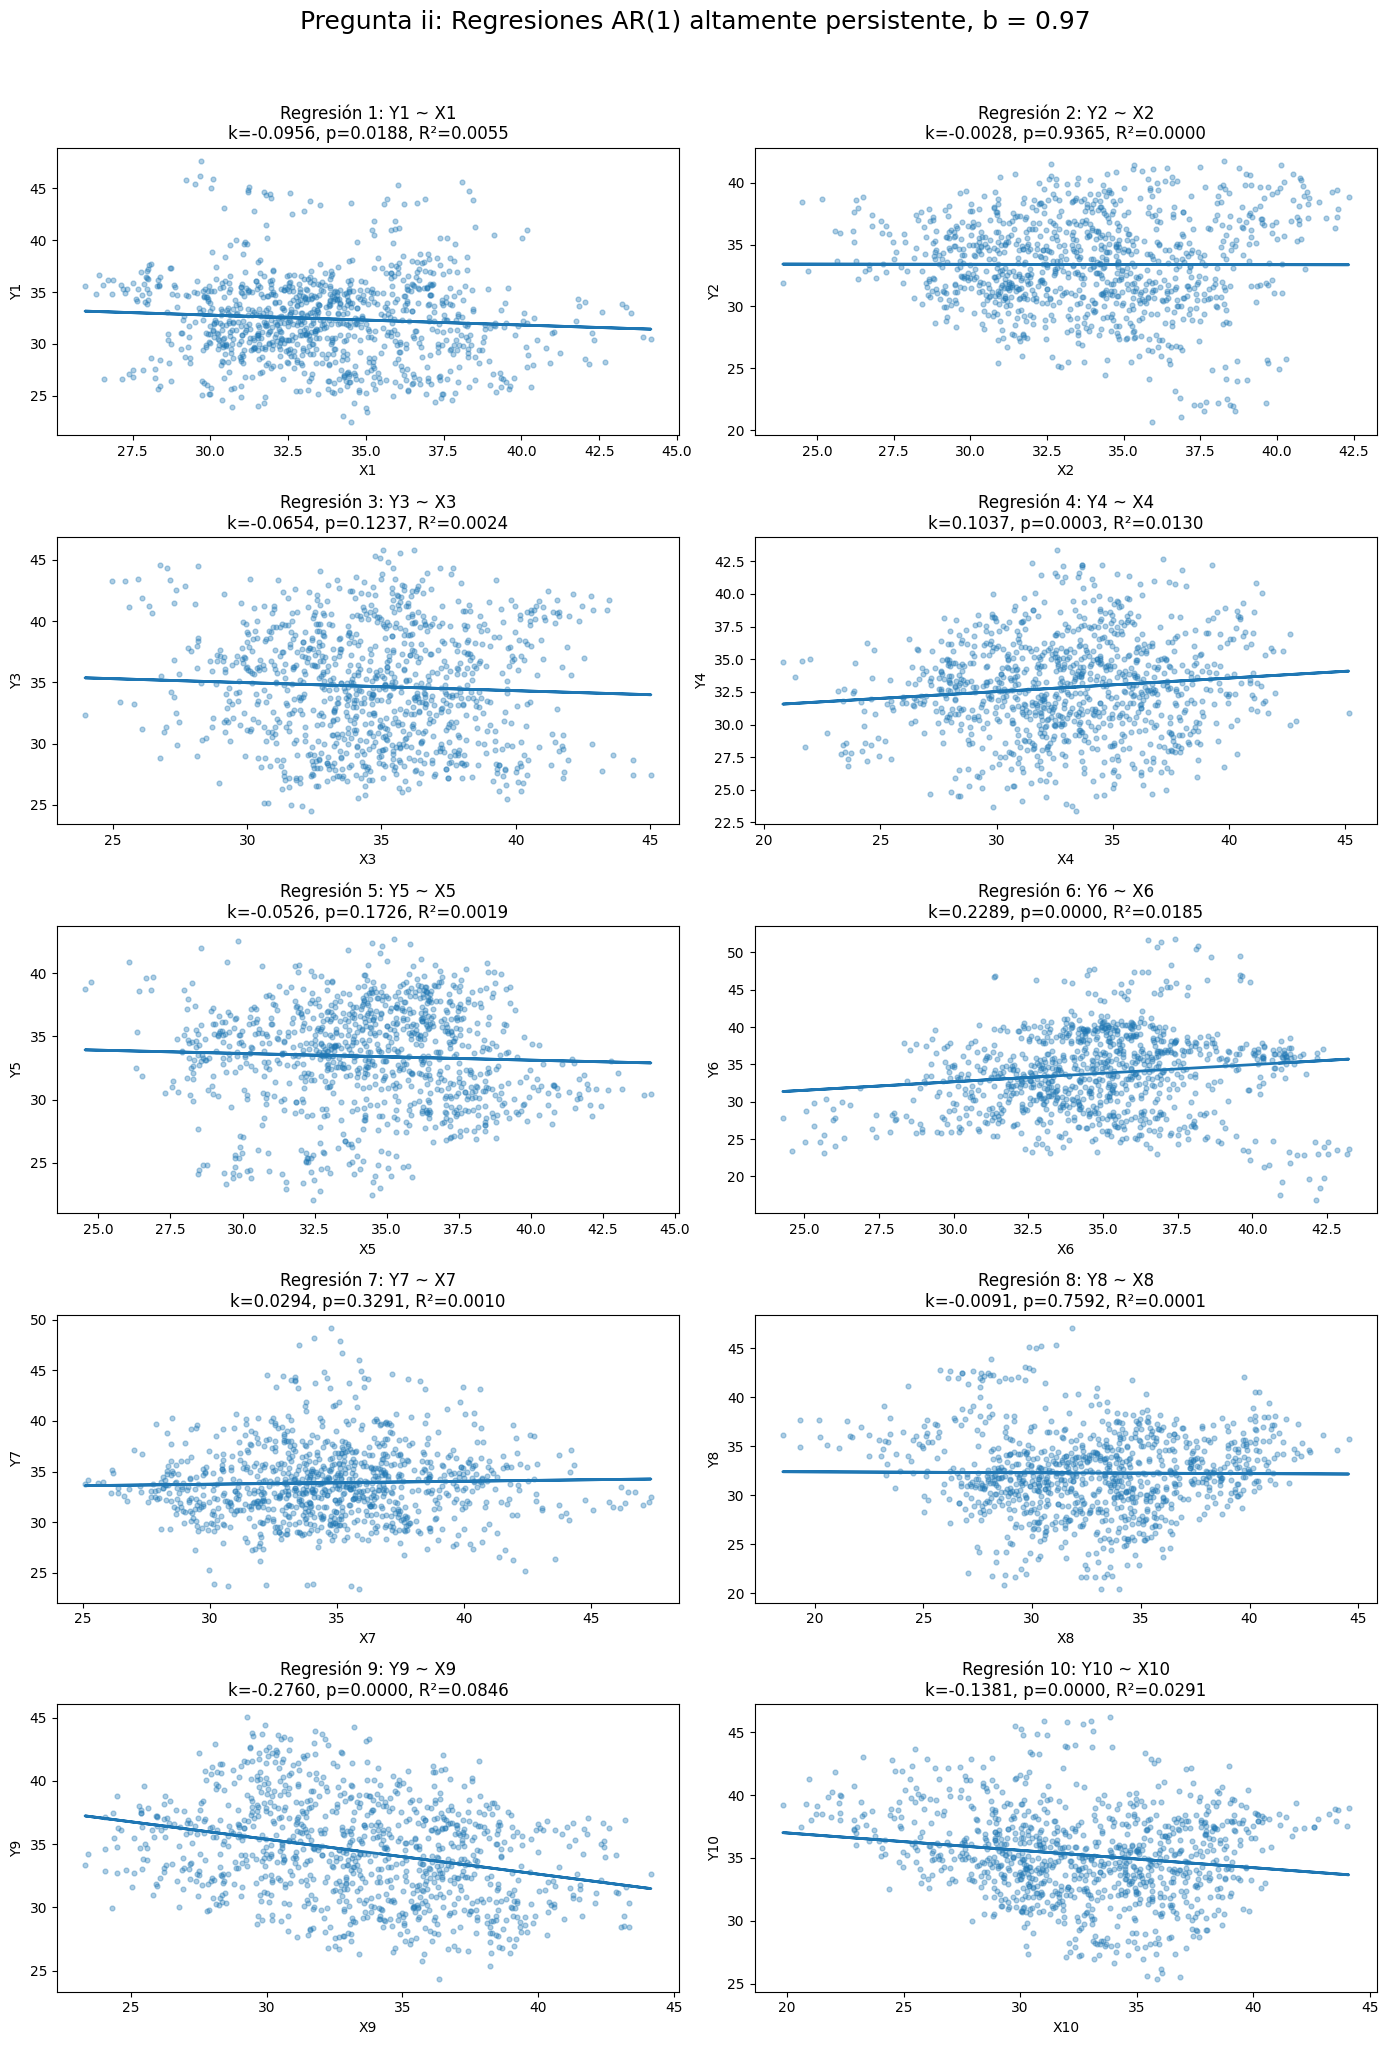

In [33]:
resumen_graficos_ii = graficar_regresiones(
    Y_persistente,
    X_persistente,
    "Pregunta ii: Regresiones AR(1) altamente persistente, b = 0.97",
    "Pregunta_ii_AR1_persistente"
)

### Bloque 11 — Simulación pregunta III - Random Walk con b = 1

In [34]:
np.random.seed(123)

T = 1000
n_series = 20

shocks_iii = np.random.normal(0, 1, size=(T, n_series))
y0_random = np.random.normal(0, 1, size=n_series)

series_iii = np.zeros((T, n_series))

for j in range(n_series):
    series_iii[:, j] = simular_random_walk(
        shocks=shocks_iii[:, j],
        y0=y0_random[j]
    )

Y_rw = series_iii[:, :10]
X_rw = series_iii[:, 10:]

### Bloque 12 — Regresiones pregunta III

In [35]:
resultados_iii = regresiones_y_significancia(
    Y_rw,
    X_rw,
    alpha=0.05,
    maxlags_hac=12
)

resultados_iii

,Regresión,k estimado,p-value usual,Significativo usual,p-value HAC,Significativo HAC,R2
0,Y1 ~ X1,-0.521816,2.846734e-46,True,1.028629e-04,True,0.184925
1,Y2 ~ X2,-0.108216,5.808728e-06,True,2.221037e-01,False,0.020391
2,Y3 ~ X3,1.013796,2.830095e-193,True,0.000000e+00,True,0.585903
3,Y4 ~ X4,0.071328,3.513381e-02,True,4.228434e-01,False,0.004440
4,Y5 ~ X5,0.435777,3.644313e-71,True,3.034406e-09,True,0.273091
5,Y6 ~ X6,0.545405,5.845806e-56,True,1.200382e-03,True,0.220423
6,Y7 ~ X7,0.330217,9.032412e-118,True,1.776357e-15,True,0.413509
7,Y8 ~ X8,0.259790,8.598655e-30,True,8.558487e-04,True,0.120894
8,Y9 ~ X9,0.207617,1.064037e-14,True,1.183211e-02,True,0.058163
9,Y10 ~ X10,-1.060718,3.360463e-264,True,0.000000e+00,True,0.701431


### Bloque 13 — Porcentaje de significancia pregunta III

In [36]:
porcentaje_usual_iii = resultados_iii["Significativo usual"].mean() * 100
porcentaje_hac_iii = resultados_iii["Significativo HAC"].mean() * 100

print(f"Porcentaje significativo al 5% con errores usuales: {porcentaje_usual_iii:.2f}%")
print(f"Porcentaje significativo al 5% con errores HAC: {porcentaje_hac_iii:.2f}%")

Porcentaje significativo al 5% con errores usuales: 100.00%
Porcentaje significativo al 5% con errores HAC: 80.00%


En el caso random walk, con b = 1 y a = 0, el parámetro k resulta significativo al 5% en el 100% de las regresiones utilizando errores estándar usuales.

Al utilizar errores estándar HAC, el porcentaje de significancia disminuye a 80%, pero sigue siendo extremadamente alto.

Este resultado es muy relevante, porque las series Y y X fueron generadas de manera independiente. Por lo tanto, teóricamente el coeficiente k debería ser igual a cero.

La alta proporción de rechazos evidencia un caso claro de regresión espuria. Al trabajar con series no estacionarias en niveles, la regresión puede mostrar coeficientes significativos y R² elevados aunque no exista una relación verdadera entre las variables.

La corrección HAC reduce parcialmente el problema, pero no lo elimina. Esto confirma que, cuando las variables tienen raíz unitaria, no basta con corregir los errores estándar: es necesario transformar las series, por ejemplo mediante primeras diferencias, retornos o técnicas de cointegración cuando corresponda.

| Escenario | Nivel | Significancia usual | Significancia HAC |
|---|---:|---:|---:|
| Random Walk, b = 1 | 5% | 100% | 80% |

### Bloque 14 — Gráficos pregunta III

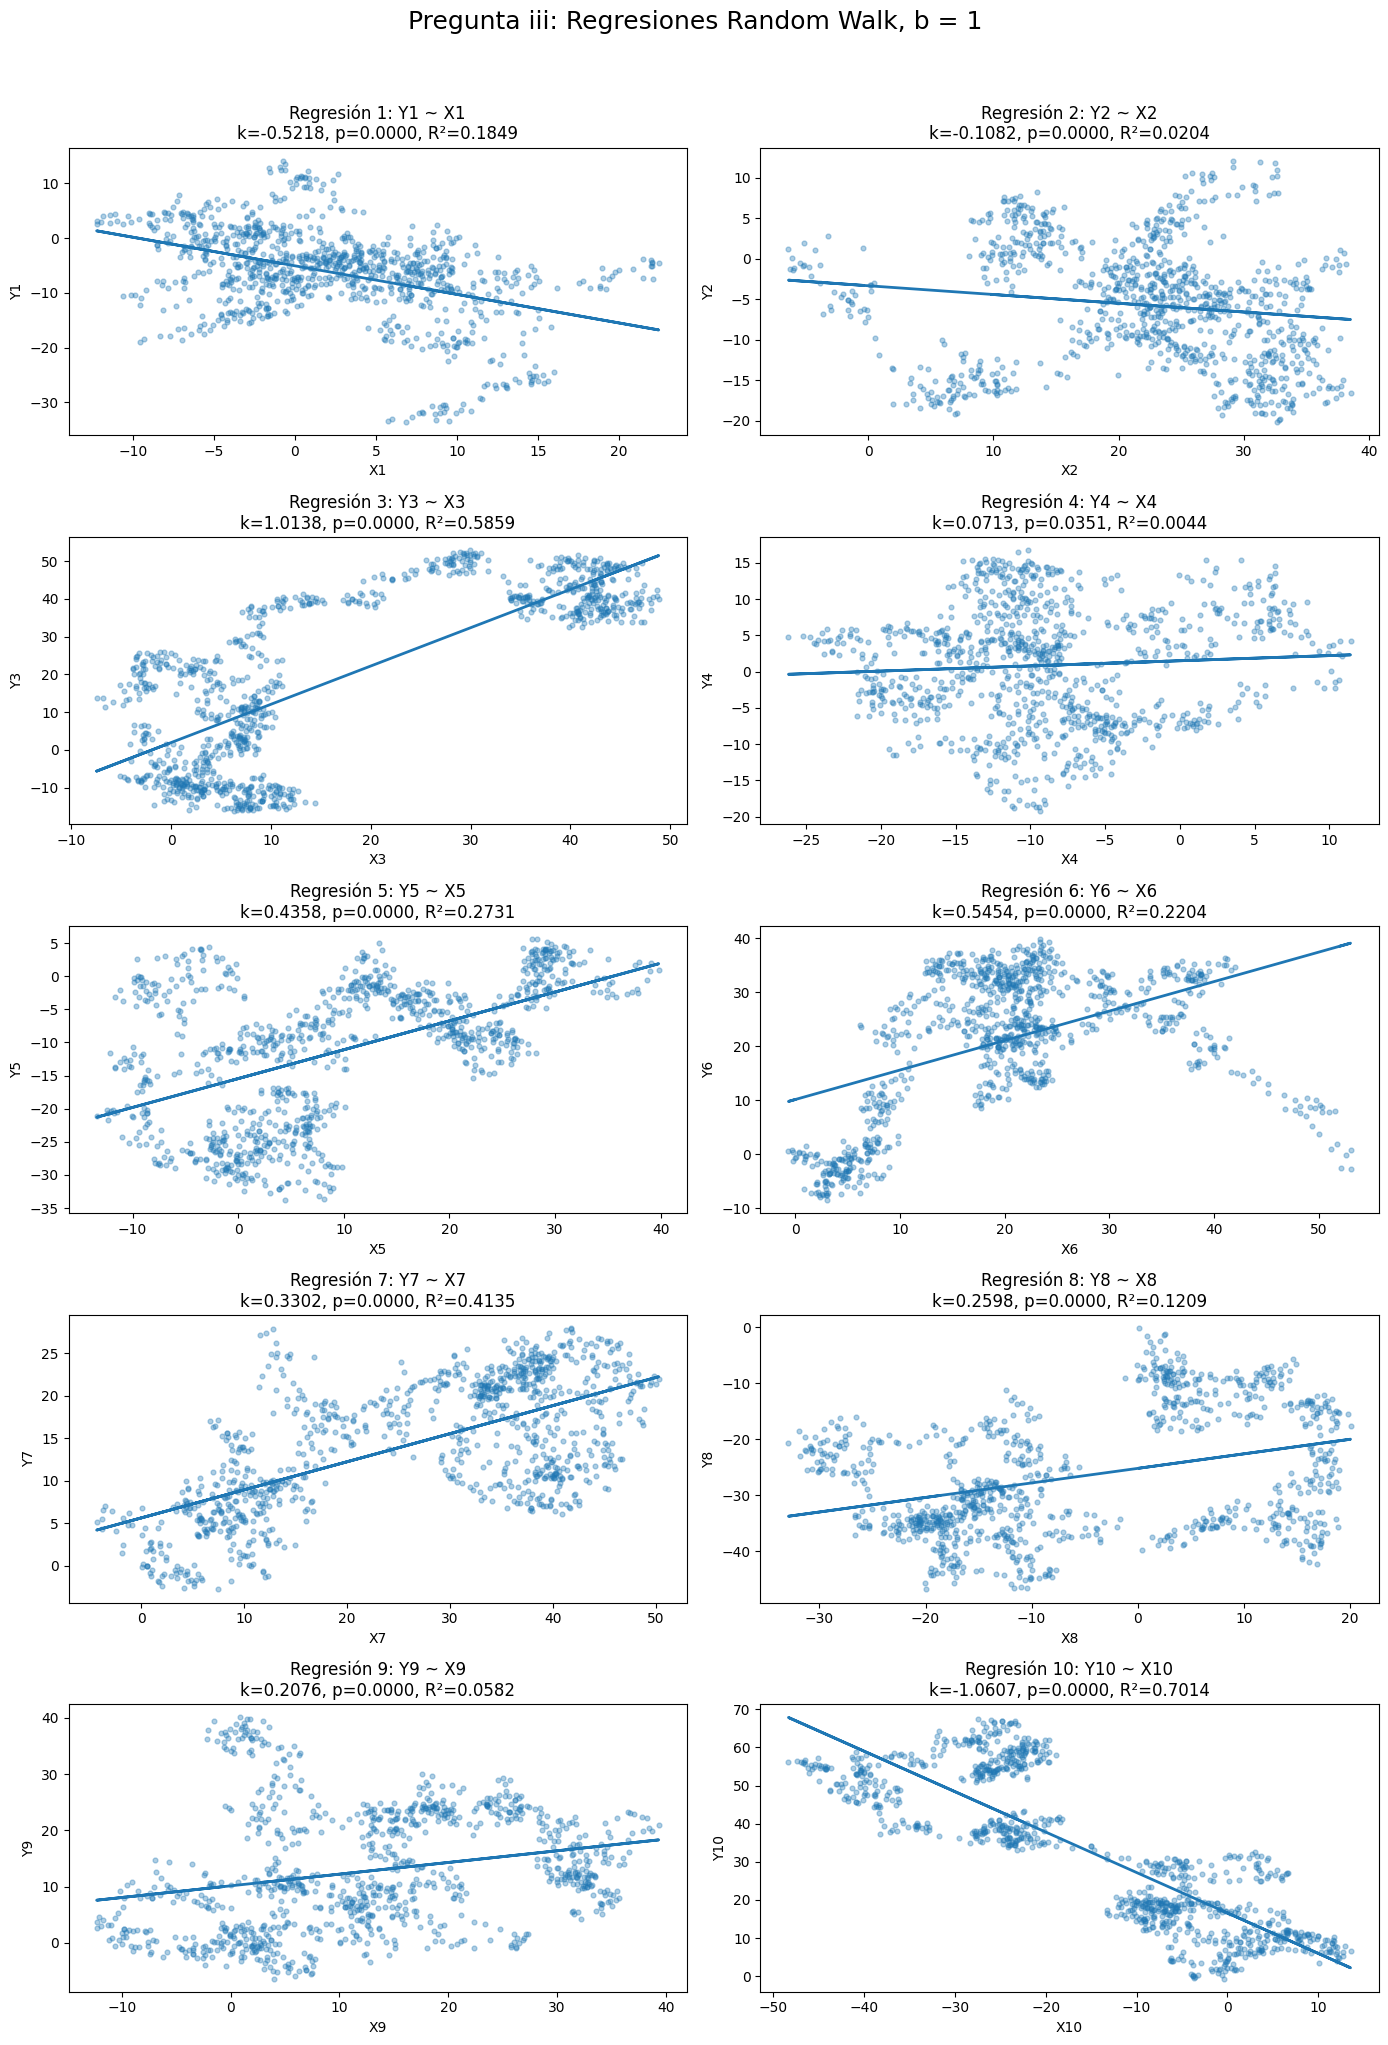

In [37]:
resumen_graficos_iii = graficar_regresiones(
    Y_rw,
    X_rw,
    "Pregunta iii: Regresiones Random Walk, b = 1",
    "Pregunta_iii_Random_Walk"
)

### Bloque 15 — Cuadro resumen de significancia

In [38]:
cuadro_resultados_final = pd.DataFrame({
    "Escenario": [
        "i) AR(1) estacionario",
        "ii) AR(1) altamente persistente",
        "iii) Random Walk"
    ],
    "Valor de b": [
        "0.6",
        "0.97",
        "1.0"
    ],
    "Nivel de significancia": [
        "10%",
        "10%",
        "5%"
    ],
    "% significativo usual": [
        porcentaje_usual_i,
        porcentaje_usual_ii,
        porcentaje_usual_iii
    ],
    "% significativo HAC": [
        porcentaje_hac_i,
        porcentaje_hac_ii,
        porcentaje_hac_iii
    ],
    "R2 promedio": [
        resultados_i["R2"].mean(),
        resultados_ii["R2"].mean(),
        resultados_iii["R2"].mean()
    ],
    "R2 máximo": [
        resultados_i["R2"].max(),
        resultados_ii["R2"].max(),
        resultados_iii["R2"].max()
    ]
})

cuadro_resultados_final

,Escenario,Valor de b,Nivel de significancia,% significativo usual,% significativo HAC,R2 promedio,R2 máximo
0,i) AR(1) estacionario,0.6,10%,40.0,20.0,0.003455,0.011521
1,ii) AR(1) altamente persistente,0.97,10%,50.0,20.0,0.015608,0.084576
2,iii) Random Walk,1.0,5%,100.0,80.0,0.258317,0.701431


### Bloque 16 — Cuadro resumen interpretativo de los gráficos

In [39]:
cuadro_resumen_graficos = pd.DataFrame({
    "Escenario": [
        "i) AR(1) estacionario",
        "ii) AR(1) altamente persistente",
        "iii) Random Walk"
    ],
    "Tipo de proceso": [
        "Estacionario",
        "Estacionario, pero muy persistente",
        "No estacionario / raíz unitaria"
    ],
    "Relación real entre Y y X": [
        "No existe relación real",
        "No existe relación real",
        "No existe relación real"
    ],
    "Comportamiento gráfico esperado": [
        "Nube de puntos dispersa, sin patrón fuerte",
        "Puede aparecer una relación visual artificial",
        "Puede aparecer una relación visual espuria"
    ],
    "Interpretación": [
        "La significancia debería estar cerca del nivel nominal",
        "La persistencia aumenta el riesgo de falsos positivos",
        "La no estacionariedad puede generar regresión espuria"
    ],
    "Riesgo de regresión espuria": [
        "Bajo",
        "Medio/Alto",
        "Muy alto"
    ]
})

cuadro_resumen_graficos

,Escenario,Tipo de proceso,Relación real entre Y y X,Comportamiento gráfico esperado,Interpretación,Riesgo de regresión espuria
0,i) AR(1) estacionario,Estacionario,No existe relación real,"Nube de puntos dispersa, sin patrón fuerte",La significancia debería estar cerca del nivel...,Bajo
1,ii) AR(1) altamente persistente,"Estacionario, pero muy persistente",No existe relación real,Puede aparecer una relación visual artificial,La persistencia aumenta el riesgo de falsos po...,Medio/Alto
2,iii) Random Walk,No estacionario / raíz unitaria,No existe relación real,Puede aparecer una relación visual espuria,La no estacionariedad puede generar regresión ...,Muy alto


### Bloque 17 - Exportar Tablas

In [40]:
# NUEVO BLOQUE: Exportar todas las tablas a Excel
def exportar_tabla_excel(df, nombre_archivo):
    ruta = TABLES_DIR / f"{nombre_archivo}.xlsx"
    df.to_excel(ruta, index=False)
    print(f"Tabla exportada: {ruta}")

# Exportar las 3 tablas de resultados de regresiones
exportar_tabla_excel(resultados_i, "resultados_i_AR1_estacionario")
exportar_tabla_excel(resultados_ii, "resultados_ii_AR1_persistente")
exportar_tabla_excel(resultados_iii, "resultados_iii_Random_Walk")

# Exportar los cuadros resumen finales
exportar_tabla_excel(cuadro_resultados_final, "cuadro_resultados_final")
exportar_tabla_excel(cuadro_resumen_graficos, "cuadro_resumen_graficos")


Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\tables\parte1\resultados_i_AR1_estacionario.xlsx
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\tables\parte1\resultados_ii_AR1_persistente.xlsx
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\tables\parte1\resultados_iii_Random_Walk.xlsx
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\tables\parte1\cuadro_resultados_final.xlsx
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\tables\parte1\cuadro_resumen_graficos.xlsx


# Respuestas teóricas

## Pregunta IV:
Si los procesos Yi(t) y Xi(t) son independientes entre sí, el valor teórico del parámetro k debería ser cero.

Esto ocurre porque no existe una relación estadística verdadera entre ambas series. Las series fueron generadas a partir de shocks independientes, por lo tanto, cualquier coeficiente distinto de cero obtenido en la regresión corresponde a variación muestral, error tipo I o, en casos más graves, a regresión espuria.

# Pregunta V:
 Si k es exactamente igual a cero y se realiza inferencia con un nivel de significancia del 10%, se esperaría rechazar la hipótesis nula k = 0 aproximadamente el 10% de las veces.

Ese 10% corresponde al error tipo I, es decir, rechazar una hipótesis nula verdadera.

Sin embargo, esta conclusión depende de que se cumplan las condiciones estadísticas tradicionales. Cuando las series son altamente persistentes o no estacionarias, la proporción real de rechazos puede ser mayor al 10%, lo que refleja problemas de inferencia en series de tiempo.

# Pregunta VI:
Las simulaciones muestran que la inferencia en series de tiempo puede ser engañosa cuando las variables presentan alta persistencia o raíz unitaria.

En el primer caso, con b = 0.6, los procesos son estacionarios y relativamente poco persistentes. Por lo tanto, la proporción de rechazos de la hipótesis nula k = 0 debería estar relativamente cerca del nivel de significancia utilizado.

En el segundo caso, con b = 0.97, los procesos siguen siendo estacionarios, pero son altamente persistentes. Esto puede generar una apariencia de relación entre variables independientes y elevar la proporción de falsos rechazos.

En el tercer caso, con b = 1, las series son random walks no estacionarios. Este escenario es el más problemático, porque las regresiones en niveles entre series independientes pueden producir coeficientes significativos, R2 elevados y patrones visuales aparentemente fuertes, aun cuando no exista relación verdadera.

En consecuencia, antes de estimar regresiones con series de tiempo, es fundamental analizar la estacionariedad. Si las variables no son estacionarias, se debe considerar trabajar con primeras diferencias, retornos, cointegración u otros métodos adecuados.

### Bloque Python para exportar tablas a LaTeX

In [41]:
import os

LATEX_DIR = os.path.join(RESULTS_DIR, "latex_tables/parte1")
os.makedirs(LATEX_DIR, exist_ok=True)

def exportar_tabla_latex(df, nombre_archivo, caption, label, columnas=None, n=10):
    tabla = df.copy()
    
    if columnas is not None:
        tabla = tabla[columnas]
    
    tabla = tabla.head(n)
    
    ruta = os.path.join(LATEX_DIR, nombre_archivo)
    
    latex = tabla.to_latex(
        index=False,
        float_format="%.4f",
        caption=caption,
        label=label,
        escape=False,
        longtable=False,
        bold_rows=False
    )
    
    with open(ruta, "w", encoding="utf-8") as f:
        f.write(latex)
    
    print(f"Tabla exportada: {ruta}")

### Bloque Exportar Tablas

In [44]:
exportar_tabla_latex(resultados_i, "resultados_i_AR1_estacionario.tex", "Resultados de Regresión: AR(1) estacionario (b=0.6)", "tab:res_i")
exportar_tabla_latex(resultados_ii, "resultados_ii_AR1_persistente.tex", "Resultados de Regresión: AR(1) altamente persistente (b=0.97)", "tab:res_ii")
exportar_tabla_latex(resultados_iii, "resultados_iii_Random_Walk.tex", "Resultados de Regresión: Caminata Aleatoria (Random Walk)", "tab:res_iii")
# Exportar los cuadros resumen finales
exportar_tabla_latex(cuadro_resultados_final, "cuadro_resultados_final.tex", "Resumen Consolidado de Resultados de Simulación", "tab:resumen_final")
exportar_tabla_latex(cuadro_resumen_graficos, "cuadro_resumen_graficos.tex", "Resumen del Comportamiento Gráfico Esperado", "tab:resumen_graficos")
print("\n¡Exportación a LaTeX de la Parte 1 finalizada con éxito!")

Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\latex_tables/parte1\resultados_i_AR1_estacionario.tex
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\latex_tables/parte1\resultados_ii_AR1_persistente.tex
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\latex_tables/parte1\resultados_iii_Random_Walk.tex
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\latex_tables/parte1\cuadro_resultados_final.tex
Tabla exportada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0011\Tarea Final\results\latex_tables/parte1\cuadro_resumen_graficos.tex

¡Exportación a LaTeX de la Parte 1 finalizada con éxito!


In [ ]:
import os

LATEX_DIR = os.path.join(RESULTS_DIR, "latex_tables")
os.makedirs(LATEX_DIR, exist_ok=True)

def exportar_tabla_latex(df, nombre_archivo, caption, label, columnas=None, n=10):
    tabla = df.copy()
    
    if columnas is not None:
        tabla = tabla[columnas]
    
    tabla = tabla.head(n)
    
    ruta = os.path.join(LATEX_DIR, nombre_archivo)
    
    latex = tabla.to_latex(
        index=False,
        float_format="%.4f",
        caption=caption,
        label=label,
        escape=False,
        longtable=False,
        bold_rows=False
    )
    
    with open(ruta, "w", encoding="utf-8") as f:
        f.write(latex)
    
    print(f"Tabla exportada: {ruta}")